# 01 — Perfil e auditoria dos dados
**Projeto:** PI 4CCOMP 2026/2 — CTI Global
**Fase CRISP-DM:** Entender os Dados
**Fonte:** Demonstrativo Fecap v3.csv (CTI Global, recebido em 21/08/2026)

Objetivo: descrever a estrutura do arquivo, explorar seu conteúdo
e verificar a qualidade dos dados antes de qualquer transformação.

**Contexto informado pela CTI (08/09/2026):** os dados são **projetados**, não históricos, e
representam uma concessionária de infraestrutura. Os 1.200 cenários vêm de uma **simulação de
Monte Carlo** — são 1.200 futuros possíveis da mesma concessão, não 1.200 empresas. Por convenção
acadêmica, **Ano 1 = 2027 … Ano 12 = 2038**. O Ano 12 é o **encerramento da concessão**.

**Revisão de 15/09/2026:** corrigida a verificação do balanço (convenção de sinais) e as
interpretações das linhas sem nome de conta e dos cenários repetidos. Detalhes em cada seção.

In [1]:
import pandas as pd

## Coletar dados iniciais

Primeira tarefa da fase *Entender os Dados* do CRISP-DM: carregar o arquivo bruto
sem alterar nada nele. O arquivo da CTI não segue o padrão que o `read_csv` assume
por default, então cada parâmetro abaixo corrige uma diferença específica.


In [2]:
from pathlib import Path

# O caminho relativo simples quebra porque o Jupyter nem sempre roda a partir
# da pasta do notebook. A solução: subir a partir do diretório atual até achar
# a raiz do repositório (a pasta que contém src/data/raw).
raiz = Path.cwd()
while not (raiz / "src" / "data" / "raw").exists() and raiz != raiz.parent:
    raiz = raiz.parent

CAMINHO = raiz / "src" / "data" / "raw" / "Demonstrativo Fecap v3.csv"
print("lendo de:", CAMINHO)

df = pd.read_csv(
    CAMINHO,
    sep=";",                                     # as colunas são separadas por ponto e vírgula
    header=None,                                 # o arquivo não tem linha de cabeçalho
    names=["ano", "cenario", "conta", "valor"],  # por isso nomeamos as 4 colunas aqui
    encoding="latin-1",                          # sem isso os acentos vêm quebrados
    decimal=",",                                 # no arquivo a vírgula é o separador decimal
    thousands=".",                               # e o ponto é o separador de milhar
)

df.head()

lendo de: C:\Users\Gusta\OneDrive\Documentos\GitHub\Projeto6\src\data\raw\Demonstrativo Fecap v3.csv


,ano,cenario,conta,valor
0,Ano 1,Total Cen_00001,NaN,2.513881e-02
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07


### Conferindo se a leitura funcionou

Três verificações antes de seguir:

1. **1.002.000 linhas e 4 colunas**
2. **`valor` como `float64`** — se vier como texto, a conversão numérica não aconteceu
3. **valores na casa dos bilhões** — se o máximo vier em milhares, o separador de milhar foi lido errado


In [3]:
print("linhas e colunas:", df.shape)
print()
print(df.dtypes)   # 'valor' precisa ser float64; as outras três são texto
print()
print("valor mínimo:", df["valor"].min())
print("valor máximo:", df["valor"].max())

linhas e colunas: (1002000, 4)

ano            str
cenario        str
conta          str
valor      float64
dtype: object

valor mínimo: -15879812955.3528
valor máximo: 15821841345.9487


## Descrever os dados

Segunda tarefa do CRISP-DM. O objetivo aqui é responder *"o que existe dentro
deste arquivo?"* — ainda sem interpretar nada, só levantando a estrutura.


In [4]:
# Quantos valores diferentes existem em cada coluna.
# nunique() ignora valores nulos automaticamente.
print("anos distintos    :", df["ano"].nunique())
print("cenários distintos:", df["cenario"].nunique())
print("contas distintas  :", df["conta"].nunique())

anos distintos    : 12
cenários distintos: 1200
contas distintas  : 69


In [5]:
# Quais são os anos. Ordenamos pelo número, não pelo texto:
# em ordem alfabética "Ano 10" viria antes de "Ano 2".
anos = sorted(df["ano"].unique(), key=lambda a: int(a.split()[1]))
print(anos)

# Os cenários são muitos, então olhamos só os extremos
cenarios = sorted(df["cenario"].unique())
print("\nprimeiro:", cenarios[0], "| último:", cenarios[-1], "| total:", len(cenarios))

['Ano 1', 'Ano 2', 'Ano 3', 'Ano 4', 'Ano 5', 'Ano 6', 'Ano 7', 'Ano 8', 'Ano 9', 'Ano 10', 'Ano 11', 'Ano 12']

primeiro: Total Cen_00001 | último: Total Cen_01200 | total: 1200


In [6]:
# Existem linhas sem nome de conta?
print("linhas com conta vazia:", df["conta"].isna().sum())

# A lista completa das 69 contas
for c in sorted(df["conta"].dropna().unique()):
    print(c)

linhas com conta vazia: 43200
BAL  - Capital Social
BAL  - Dividendos Antecipados
BAL  - Patrimônio Líquido
BAL  - Prov para Contingências
BAL  - Reserva de Retenção de Lucros
BAL  - Reservas Legais
BAL  - Reservas de Capital
BAL  - Resultado Acumulado
BAL  - Resultado do Período
BAL - Amortização - Intangível
BAL - Amortização Acumulada
BAL - At Fiscal Diferido
BAL - Ativo Circulante
BAL - Contas a Pagar - Parte Relacionada
BAL - Contas a Receber - Clientes
BAL - Contas a Receber - Partes Relacionadas
BAL - Contas a Receber - SWAP
BAL - Créditos Tributários
BAL - Depreciação Acumulada
BAL - Diferido
BAL - Disponível
BAL - Emprést
BAL - Empréstimos
BAL - Encargos Sociais e Trabalhistas
BAL - Estoques Diversos
BAL - Exigível a Longo Prazo
BAL - Fornecedores
BAL - Impostos
BAL - Investimentos - Imobilizado
BAL - Investimentos - Intangível
BAL - Obrigações com o Poder Concedente
BAL - Outorga da Concessão
BAL - Outros Créditos
BAL - Outros Créditos LP
BAL - Outros Débitos
BAL - Outros deb

In [7]:
# Quantas linhas há em cada bloco de conta.
# O prefixo é o texto antes do primeiro " - ": split(" - ") quebra o nome
# em pedaços e .str[0] pega o primeiro.
bloco = df["conta"].str.split(" - ").str[0]
print(bloco.value_counts(dropna=False))

# ATENÇÃO ao resultado: um dos blocos aparece DUAS vezes na contagem.
# Isso não é bug do código — é uma inconsistência no arquivo. Investigue por quê.

conta
BAL     468000
DRE     201600
FLU     172800
BAL     116400
NaN      43200
Name: count, dtype: int64


In [8]:
# Resumo estatístico da única coluna numérica
df["valor"].describe()

count    1.002000e+06
mean     4.064611e+08
std      3.460617e+09
min     -1.587981e+10
25%     -5.863950e+08
50%     -2.054438e+05
75%      8.236062e+08
max      1.582184e+10
Name: valor, dtype: float64

### Leitura dos resultados

- O arquivo tem **1.002.000 linhas**: 12 anos de horizonte (2027 a 2038, por convenção)
  × 1.200 cenários de Monte Carlo.
- As contas se dividem em três blocos: **`BAL`** (balanço patrimonial, 43 contas), **`DRE`**
  (demonstração do resultado, 14 contas) e **`FLU`** (fluxo de caixa, 12 contas).
- Existem **43.200 linhas sem nome de conta**, exatamente 3 por par ano×cenário. A primeira
  guarda o resíduo de conferência do balanço (verificação V5); as outras duas são sempre zero.
- O bloco `BAL` aparece **duas vezes** na contagem porque parte das contas usa `"BAL - "` e parte
  usa `"BAL  - "`, com dois espaços. É variação de digitação na origem, não um bloco novo.
- Há valores negativos e positivos porque a base segue uma **convenção de sinais**: no balanço,
  ativo é positivo (débito) e passivo e patrimônio líquido são negativos (crédito); na DRE e no
  fluxo de caixa, entradas são positivas e saídas (custos, tributos, distribuição aos acionistas)
  são negativas. **Valor negativo não é erro.**

## Explorar os dados e verificar a qualidade

Terceira e quarta tarefas do CRISP-DM.

**Descrever** é perguntar ao dado o que ele é. **Verificar a qualidade** é afirmar primeiro o que
*deveria* ser verdade e testar. Cada verificação abaixo (V1 a V7) declara a expectativa antes do teste.

> **Nota de revisão (15/09/2026):** a versão de 29/08 subtraía o passivo do ativo e concluía que o
> balanço não fechava. Isso estava errado — o passivo é gravado com sinal negativo, e a conta correta
> é a soma (V4). A mesma versão tratava a linha sem nome como possível taxa e os valores repetidos
> como um piso do modelo; as duas interpretações foram substituídas pelas verificações V5 e V7.

### V1 — cada ano tem as mesmas contas?

**Expectativa:** os 12 anos trazem as mesmas 69 contas.

`groupby("ano")` separa as linhas por ano e `["conta"].nunique()` conta quantos nomes diferentes de
conta existem em cada um. O `reindex` só coloca os anos em ordem numérica.

In [9]:
# Ordem numérica dos anos (e não alfabética)
ordem_anos = sorted(df["ano"].unique(), key=lambda a: int(a.split()[1]))

contas_por_ano = df.groupby("ano")["conta"].nunique().reindex(ordem_anos)
print(contas_por_ano.to_string())

ano
Ano 1     68
Ano 2     68
Ano 3     69
Ano 4     69
Ano 5     69
Ano 6     69
Ano 7     69
Ano 8     69
Ano 9     69
Ano 10    69
Ano 11    69
Ano 12    42


### V2 — todo par (ano, cenário) tem o mesmo tamanho?

**Expectativa:** cada combinação de ano e cenário tem a mesma quantidade de contas.

São 12 × 1.200 = 14.400 grupos. `value_counts()` resume quantos grupos têm cada tamanho.

In [10]:
contagem = df.groupby(["ano", "cenario"])["conta"].count()

print("total de grupos (ano x cenário):", len(contagem))
print()
print("quantos grupos têm cada quantidade de contas:")
print(contagem.value_counts().sort_index().to_string())

total de grupos (ano x cenário): 14400

quantos grupos têm cada quantidade de contas:
conta
42     1200
68     2400
69    10800


### V3 — (ano, cenário, conta) é uma chave única? O que são as linhas sem nome?

**Expectativa:** as três colunas juntas identificam uma única linha.

`duplicated` marca repetições. Depois olhamos as linhas sem nome de conta **pela posição dentro do
grupo** (1ª, 2ª e 3ª), para ver se elas têm papéis diferentes.

In [11]:
# Número do ano como inteiro, para agrupar e ordenar ("Ano 7" -> 7)
df["ano_n"] = df["ano"].str.split().str[1].astype(int)

n_dup = df.duplicated(subset=["ano", "cenario", "conta"]).sum()
todas = df.duplicated(subset=["ano", "cenario", "conta"], keep=False)
print("linhas duplicadas          :", n_dup)
print("linhas envolvidas          :", int(todas.sum()))
print("dessas, com conta vazia    :", int(df.loc[todas, "conta"].isna().sum()))
print()

# Numera as linhas sem nome dentro de cada par ano x cenário: 1ª, 2ª e 3ª
sem_nome = df[df["conta"].isna()].copy()
sem_nome["ordem"] = sem_nome.groupby(["cenario", "ano_n"]).cumcount() + 1
print("valores das linhas sem nome, por posição no grupo:")
print(sem_nome.groupby("ordem")["valor"].agg(["count", "min", "max"]).to_string())

linhas duplicadas          : 28800
linhas envolvidas          : 43200
dessas, com conta vazia    : 43200

valores das linhas sem nome, por posição no grupo:
       count      min       max
ordem                          
1      14400 -0.02511  0.025153
2      14400  0.00000  0.000000
3      14400  0.00000  0.000000


### Preparando o terreno: a tabela cruzada

As próximas verificações comparam contas **entre si**, então cada conta precisa virar coluna.
`pivot_table` gera uma linha por cenário + ano e uma coluna por conta: 14.400 × 69.

Antes, criamos `conta_norm` — o nome da conta com espaços normalizados — **só para esta tabela**,
para que `"BAL  - Patrimônio Líquido"` e `"BAL - Patrimônio Líquido"` sejam a mesma coluna.
A coluna original `conta` não é alterada.

In [12]:
nomeadas = df[df["conta"].notna()].copy()
nomeadas["conta_norm"] = nomeadas["conta"].str.replace(r"\s+", " ", regex=True).str.strip()

p = nomeadas.pivot_table(
    index=["cenario", "ano_n"],
    columns="conta_norm",
    values="valor",
    aggfunc="sum",
)
print("formato da tabela cruzada:", p.shape)
p.head(3)

formato da tabela cruzada: (14400, 69)


conta_norm             BAL - Amortização - Intangível  \
cenario         ano_n                                   
Total Cen_00001 1                       -5.047124e+09   
                2                       -5.710884e+09   
                3                       -6.417036e+09   

conta_norm             BAL - Amortização Acumulada  BAL - At Fiscal Diferido  \
cenario         ano_n                                                          
Total Cen_00001 1                    -3.011128e+07             -1.039693e+08   
                2                    -4.054538e+07              1.636680e+08   
                3                    -5.334893e+07              4.649431e+08   

conta_norm             BAL - Ativo Circulante  BAL - Capital Social  \
cenario         ano_n                                                 
Total Cen_00001 1                1.795721e+09          -309618939.0   
                2                1.567979e+09          -309618939.0   
                3                2.292584e+09          -309618939.0   

conta_norm             BAL - Contas a Pagar - Parte Relacionada  \
cenario         ano_n                                             
Total Cen_00001 1                                 -1.408627e+07   
                2                                 -1.433214e+07   
                3                                 -1.433214e+07   

conta_norm             BAL - Contas a Receber - Clientes  \
cenario         ano_n                                      
Total Cen_00001 1                           4.538710e+08   
                2                           4.055679e+08   
                3                           4.055679e+08   

conta_norm             BAL - Contas a Receber - Partes Relacionadas  \
cenario         ano_n                                                 
Total Cen_00001 1                                     584661.466883   
                2                                     584661.466883   
                3                                     584661.466883   

conta_norm             BAL - Contas a Receber - SWAP  \
cenario         ano_n                                  
Total Cen_00001 1                       9.568042e+07   
                2                       1.625707e+08   
                3                       2.248569e+08   

conta_norm             BAL - Créditos Tributários  ...  \
cenario         ano_n                              ...   
Total Cen_00001 1                    1.846453e+06  ...   
                2                    1.846453e+06  ...   
                3                    1.846453e+06  ...   

conta_norm             FLU - Distribuição para Acionista  FLU - Entradas  \
cenario         ano_n                                                      
Total Cen_00001 1                          -1.532408e+09    9.162700e+07   
                2                          -2.553746e+09    1.515790e+08   
                3                          -2.069738e+09    1.097470e+08   

conta_norm             FLU - Geração de Caixa  \
cenario         ano_n                           
Total Cen_00001 1                4.306498e+08   
                2               -1.828375e+08   
                3                7.259936e+08   

conta_norm             FLU - Imposto de Renda e Contribuição Social  \
cenario         ano_n                                                 
Total Cen_00001 1                                     -9.344728e+08   
                2                                     -1.333357e+09   
                3                                     -1.374441e+09   

conta_norm             FLU - Investimentos  FLU - Receita  \
cenario         ano_n                                       
Total Cen_00001 1            -5.340012e+08   5.396831e+09   
                2            -3.320350e+08   5.872798e+09   
                3            -1.481845e+08   6.123728e+09   

conta_norm             FLU - Resultado Financeiro  FLU - Saldo Final  \
cenario         ano_n          

### V4 — o balanço fecha?

**Expectativa:** ativo e passivo (incluindo o patrimônio líquido) têm o mesmo tamanho.

**Convenção de sinais:** nesta base o ativo é positivo e o passivo é **negativo**. Por isso a
identidade se escreve como **soma**: `Total do Ativo + Total do Passivo = 0`.

> A versão anterior deste notebook calculava `Ativo − Passivo` e obtinha "diferença média de
> R$ 15,2 bilhões". Isso era um erro de sinal do teste, não um problema da base.

Também conferimos a estrutura: se os totais são mesmo a soma dos seus grupos.
Tolerância de R$ 1,00 — o maior resíduo é de centavos, em valores da ordem de bilhões.

In [13]:
residuo_balanco = p["BAL - Total do Ativo"] + p["BAL - Total do Passivo"]
print("grupos comparáveis        :", int(residuo_balanco.notna().sum()))
print("grupos que fecham (< R$1) :", int((residuo_balanco.abs() < 1).sum()))
print("maior resíduo (R$)        :", round(residuo_balanco.abs().max(), 4))
print()

# Total do Ativo = Ativo Circulante + Realizável LP + Permanente
estr_ativo = p["BAL - Total do Ativo"] - (
    p["BAL - Ativo Circulante"] + p["BAL - Realizável a Longo Prazo"] + p["BAL - Permanente"]
)
# Total do Passivo = Passivo Circulante + Exigível LP + Patrimônio Líquido
estr_passivo = p["BAL - Total do Passivo"] - (
    p["BAL - Passivo Circulante"] + p["BAL - Exigível a Longo Prazo"] + p["BAL - Patrimônio Líquido"]
)
print("estrutura do ativo   — comparáveis:", int(estr_ativo.notna().sum()),
      "| fecham:", int((estr_ativo.abs() < 1).sum()))
print("estrutura do passivo — comparáveis:", int(estr_passivo.notna().sum()),
      "| fecham:", int((estr_passivo.abs() < 1).sum()))

grupos comparáveis        : 14400
grupos que fecham (< R$1) : 14400
maior resíduo (R$)        : 0.0252

estrutura do ativo   — comparáveis: 14400 | fecham: 14400
estrutura do passivo — comparáveis: 13200 | fecham: 13200


### V5 — a primeira linha sem nome é o resíduo do balanço?

**Hipótese:** a V3 mostrou que a 1ª linha sem nome tem valores de alguns centavos e as outras duas
são sempre zero. A V4 mostrou um resíduo de balanço da mesma ordem. Se forem a mesma coisa, a linha
é uma **conferência gerada pelo modelo**, e não uma conta financeira.

In [14]:
primeira_sem_nome = sem_nome[sem_nome["ordem"] == 1].set_index(["cenario", "ano_n"])["valor"]
diferenca = (primeira_sem_nome - residuo_balanco).dropna()

print("pares comparados :", len(diferenca))
print("maior diferença  :", diferenca.abs().max())

pares comparados : 14400
maior diferença  : 9.609513671874834e-05


### V6 — o fluxo de caixa fecha?

**Expectativa:** `Saldo Final = Saldo Inicial + Geração de Caixa`.

In [15]:
dif_fluxo = p["FLU - Saldo Final"] - (p["FLU - Saldo Inicial"] + p["FLU - Geração de Caixa"])
print("grupos comparáveis        :", int(dif_fluxo.notna().sum()))
print("grupos que fecham (< R$1) :", int((dif_fluxo.abs() < 1).sum()))
print("maior diferença           :", dif_fluxo.abs().max())

grupos comparáveis        : 14400
grupos que fecham (< R$1) : 14400
maior diferença           : 2.002716064453125e-05


### V7 — os 1.200 cenários são todos diferentes?

**Expectativa:** numa simulação de Monte Carlo, dois cenários não deveriam ter a trajetória financeira
exatamente igual.

Para comparar cenários inteiros, cada cenário vira **uma linha** com todas as contas de todos os anos
(`unstack`). Depois, `hash_pandas_object` gera uma "impressão digital" numérica de cada linha:
trajetórias idênticas produzem a mesma impressão digital.

In [16]:
trajetoria = p.unstack("ano_n")          # 1.200 cenários x (69 contas x 12 anos)
# Valores completos, sem arredondar: dois cenários só contam como iguais se forem idênticos
assinatura = pd.util.hash_pandas_object(trajetoria, index=False)
assinatura.index = trajetoria.index

repetidas = assinatura[assinatura.duplicated(keep=False)]
print("cenários com trajetória distinta:", assinatura.nunique(), "de", len(assinatura))
print("cenários com trajetória idêntica a outro:", len(repetidas))
print("faixa de identificadores envolvidos:", repetidas.index.min(), "a", repetidas.index.max())

# Marca as cópias (mantém a primeira ocorrência de cada trajetória)
copia = assinatura.duplicated(keep="first")
print("cópias que sairiam numa deduplicação:", int(copia.sum()))

cenários com trajetória distinta: 1107 de 1200
cenários com trajetória idêntica a outro: 94
faixa de identificadores envolvidos: Total Cen_01001 a Total Cen_01200
cópias que sairiam numa deduplicação: 93


### Explorar — como a receita evolui no horizonte

Até aqui olhamos estrutura. Agora olhamos **comportamento**.

A pergunta: a receita cresce ao longo dos 12 anos? E quanto os cenários discordam
entre si sobre esse valor?

**Escolha do gráfico:** linha para a tendência (o eixo X é tempo, e linha é o que mostra
evolução), com uma faixa sombreada entre o P10 e o P90 para representar a incerteza.
A linha central é a **mediana**, não a média — mediana não é distorcida por cenários extremos.


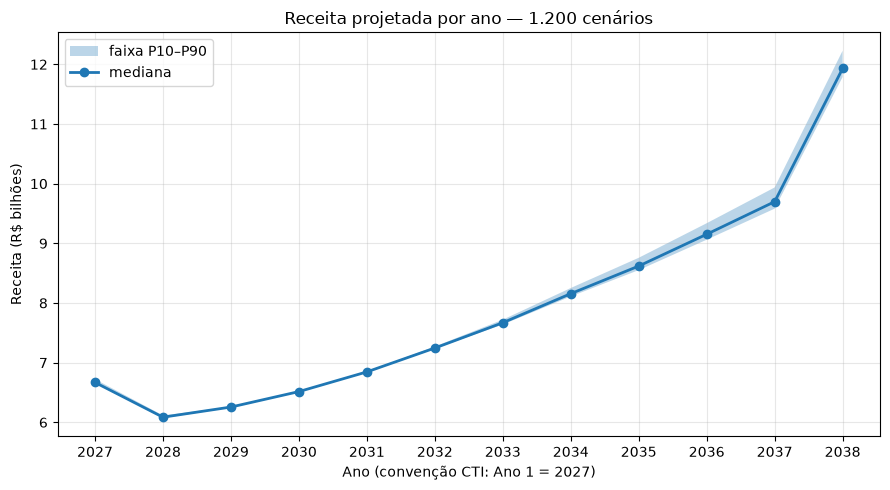

          p10  mediana     p90  cv_%
ano_n                               
1       6.657    6.669   6.723  0.53
2       6.070    6.086   6.115  0.69
3       6.245    6.256   6.260  0.89
4       6.505    6.515   6.519  1.12
5       6.841    6.845   6.849  1.34
6       7.234    7.245   7.271  1.57
7       7.640    7.669   7.720  1.82
8       8.109    8.156   8.251  2.08
9       8.551    8.619   8.758  2.36
10      9.060    9.152   9.337  2.64
11      9.581    9.698   9.936  2.94
12     11.787   11.930  12.228  2.76


In [17]:
import matplotlib.pyplot as plt

receita = nomeadas[nomeadas["conta_norm"] == "DRE - Receita"]
faixa = receita.groupby("ano_n")["valor"].agg(
    p10=lambda s: s.quantile(0.10),
    mediana="median",
    p90=lambda s: s.quantile(0.90),
) / 1e9

# Coeficiente de variação: desvio padrão / média, em %
cv = receita.groupby("ano_n")["valor"].agg(lambda s: s.std() / s.mean() * 100)

PASTA_IMG = raiz / "imagens"
PASTA_IMG.mkdir(exist_ok=True)
anos_rotulo = [str(2026 + a) for a in faixa.index]   # convenção CTI: Ano 1 = 2027

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(faixa.index, faixa["p10"], faixa["p90"], alpha=0.30, label="faixa P10–P90")
ax.plot(faixa.index, faixa["mediana"], marker="o", linewidth=2, label="mediana")
ax.set_title("Receita projetada por ano — 1.200 cenários")
ax.set_xlabel("Ano (convenção CTI: Ano 1 = 2027)")
ax.set_ylabel("Receita (R$ bilhões)")
ax.set_xticks(faixa.index)
ax.set_xticklabels(anos_rotulo)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_IMG / "01_receita_por_ano.png", dpi=150)
plt.show()

tabela = faixa.round(3)
tabela["cv_%"] = cv.round(2)
print(tabela.to_string())

**O que o gráfico mostra:**

1. A receita cai de 2027 para 2028 e depois cresce de forma sustentada até 2037.
2. Em 2038 (Ano 12) há um salto de cerca de 23%. **A CTI confirmou que o Ano 12 é o encerramento da
   concessão**, com liquidação de direitos e obrigações — por isso ele se comporta diferente dos demais.
3. A faixa P10–P90 é estreita: o coeficiente de variação da receita vai de **0,53% (2027) a 2,94% (2037)**.
   Os cenários quase não divergem sobre a receita; a incerteza simulada está em outras contas.
4. A faixa alarga com o tempo — a incerteza se acumula conforme a projeção se afasta do início.

A faixa P10–P90 descreve a dispersão entre cenários simulados. Não é intervalo de confiança.

### Explorar — como o resultado se distribui entre os cenários

Segunda pergunta: fixando um ano, quanto os 1.200 cenários discordam sobre o lucro?

**Escolha do gráfico:** histograma. Ele responde "quantos cenários caem em cada faixa de
valor", que é exatamente a pergunta. As linhas verticais marcam P10, mediana e P90 — os
mesmos números que vão virar KPI no dashboard.


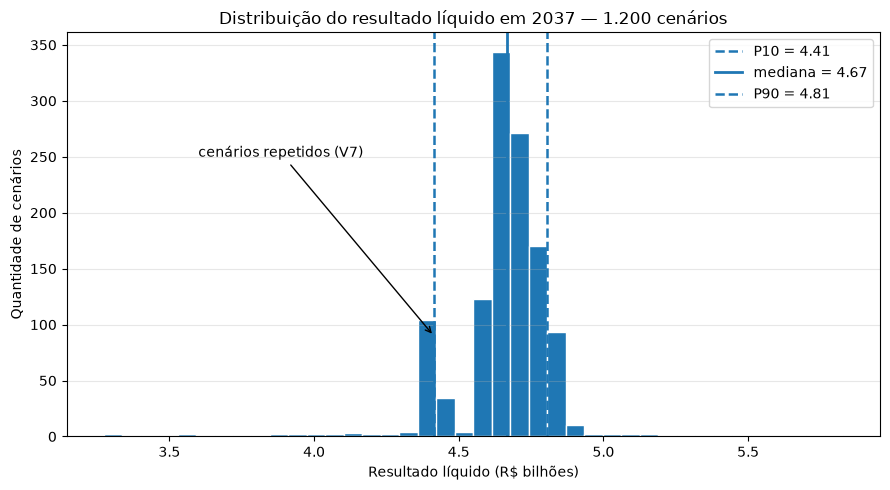

cenários: 1200 | sem cópias: 1107
cenários com prejuízo: 0

     todos os cenários  sem cópias
P5               4.414       4.458
P10              4.414       4.601
P50              4.668       4.680
P90              4.806       4.810
P95              4.840       4.845


In [18]:
ANO = 11
resultado = p.xs(ANO, level="ano_n")["DRE - Resultado Líquido"] / 1e9
sem_copias = resultado[~copia.loc[resultado.index].values]

p10, p50, p90 = resultado.quantile(0.10), resultado.median(), resultado.quantile(0.90)
valor_repetido = resultado.value_counts().index[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(resultado, bins=40, edgecolor="white")
ax.axvline(p10, linestyle="--", linewidth=1.8, label=f"P10 = {p10:.2f}")
ax.axvline(p50, linestyle="-", linewidth=2.0, label=f"mediana = {p50:.2f}")
ax.axvline(p90, linestyle="--", linewidth=1.8, label=f"P90 = {p90:.2f}")
ax.annotate("cenários repetidos (V7)", xy=(valor_repetido, 90), xytext=(3.6, 250),
            arrowprops=dict(arrowstyle="->"))
ax.set_title(f"Distribuição do resultado líquido em {2026 + ANO} — 1.200 cenários")
ax.set_xlabel("Resultado líquido (R$ bilhões)")
ax.set_ylabel("Quantidade de cenários")
ax.grid(alpha=0.3, axis="y")
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_IMG / "02_distribuicao_resultado_ano11.png", dpi=150)
plt.show()

# Efeito das cópias nos percentis
quantis = [0.05, 0.10, 0.50, 0.90, 0.95]
comparacao = pd.DataFrame({
    "todos os cenários": resultado.quantile(quantis),
    "sem cópias": sem_copias.quantile(quantis),
}).round(3)
comparacao.index = ["P5", "P10", "P50", "P90", "P95"]
print("cenários:", len(resultado), "| sem cópias:", len(sem_copias))
print("cenários com prejuízo:", int((resultado < 0).sum()))
print()
print(comparacao.to_string())

**O que o gráfico mostra:**

1. A distribuição é concentrada: quase todos os cenários entre R$ 4,4 bi e R$ 4,9 bi, com mediana
   em R$ 4,67 bi. **Nenhum dos 1.200 cenários registra prejuízo.**
2. A barra isolada perto de R$ 4,41 bi é formada pelos **cenários com trajetória idêntica** (V7).
   A versão anterior deste notebook interpretou isso como um "piso no modelo"; a V7 mostra que são
   cenários repetidos, todos na faixa `Cen_01001`–`Cen_01200`.
3. **O efeito aparece nos percentis:** com todos os cenários, P5 e P10 são iguais (R$ 4,414 bi) porque
   caem dentro do bloco repetido. Sem as cópias, os dois se separam (R$ 4,458 bi e R$ 4,601 bi).
   Qualquer KPI baseado em percentis precisa decidir, e documentar, se usa ou não esses cenários.

## Achados consolidados — fase Entender os Dados (revisão 15/09/2026)

| # | Verificação | Resultado | Impacto |
|---|---|---|---|
| V1 | Todo ano tem 69 contas | Anos 1–2 têm 68; **Ano 12 tem 42** | O Ano 12 é o encerramento da concessão (confirmado pela CTI) |
| V2 | Grupos ano×cenário do mesmo tamanho | Três tamanhos: 42, 68 e 69 | O padrão vale para todos os cenários |
| V3 | (ano, cenário, conta) é chave única | 28.800 repetições, **todas** em linhas sem nome | Nenhuma conta financeira duplicada |
| V4 | O balanço fecha | **Fecha nos 14.400 grupos** com `Ativo + Passivo`; estrutura também fecha | Base contábil consistente. Achado anterior de "R$ 15,2 bi" era erro de sinal do teste |
| V5 | 1ª linha sem nome = resíduo | Diferença máxima ≈ 0,0001 | É conferência do modelo, não taxa nem conta |
| V6 | Fluxo de caixa fecha | **Fecha nos 14.400 grupos** | Regra de validação para os KPIs |
| V7 | Cenários todos diferentes | **94 cenários idênticos** (1.107 distintos, comparação exata), todos em `Cen_01001`–`Cen_01200` | Distorce percentis (P5 = P10). Analisar com e sem cópias |
| — | Receita entre cenários | CV de 0,53% a 2,94% | A incerteza simulada não está na receita |

### Pontos em aberto para a CTI

1. Os 94 cenários idênticos são intencionais ou artefato da simulação? Devem entrar na análise?
2. `BAL - Passivo Circulante` é positivo em cerca de 63% dos grupos, puxado por `BAL - Empréstimos`.
   Qual a leitura correta desse sinal? (necessário para os índices de liquidez)
3. Qual é a memória de cálculo do `DRE - EBITDA`? Ele não reconcilia com
   `Resultado Operacional − Depreciação e Amortização`.
4. `BAL - Emprést` e `BAL - Outros deb` são contas distintas de `BAL - Empréstimos` e `BAL - Outros Débitos`?
5. Há restrição para publicar valores agregados no repositório público?

### Próxima fase

**Preparação dos Dados** (CRISP-DM): selecionar, limpar, uniformizar, derivar, integrar e formatar,
gerando a base analítica em `src/data/processed/`.